In [1]:
import os
os.environ['JAX_PLATFORMS'] = 'cpu'
import importlib
import equinox as eqx
import jax.numpy as jnp
import jax
import diffrax as dfx
import numpy as np
import matplotlib.pyplot as plt
import cobra

import MPMs.DATA_functions_01 as DF
import MPMs.UTIL_functions_01 as UF
import MPMs.ANA_functions_02 as AF
import MPMs.HELPER_functions_02 as HF
import MPMs.MPM_functions_07 as MF

importlib.reload(UF)
importlib.reload(DF)
importlib.reload(HF)
importlib.reload(AF);

In [2]:
import numpy as np
from PIL import Image, ImageOps
def trim_whitespace(path,padding=0):
    # Code from
    # https://gist.github.com/thomastweets/c7680e41ed88452d3c63401bb35116ed
    padding = np.array([-1*padding, -1*padding, padding, padding])
    image=Image.open(path)
    image.load()
    imageSize = image.size
    # remove alpha channel
    invert_im = image.convert("RGB")
    # invert image (so that white is 0)
    invert_im = ImageOps.invert(invert_im)
    imageBox = invert_im.getbbox()
    imageBox = tuple(np.asarray(imageBox)+padding)
    cropped=image.crop(imageBox)
    print("Size:", imageSize, "New Size:", imageBox)
    cropped.save(path)

def save_trim_push(path,name,padding=0,trim=True,subfolder="figures",dpi=None):
    # By default I save all my figures in a subfolder called "figures".
    # Make sure this subfolder exists before you exectue this function.
    full_path = os.path.join(path,subfolder,name)
    if dpi is None:
        dpi = plt.gcf().get_dpi()
    plt.savefig(full_path,dpi=dpi)
    if trim:
        trim_whitespace(full_path,padding)
    push2overleaf(path,name)
    return

import os
def push2overleaf(path, comment):
    # get current pwd
    tmp_pwd = os.getcwd()
    # change pwd to git repo
    os.chdir(path)
    # do git commands
    os.system("git pull")
    os.system("git add .")
    os.system('git commit -m "' + comment + '"')
    os.system("git push")
    # change pwd back
    os.chdir(tmp_pwd)
    return

git_path = "/home/mgotsmy/overleaf/688f5daf4e30e6d98498e7b8/"

# Cross Validation

## Compare Versions

In [3]:
importlib.reload(AF)
importlib.reload(UF)

versions = []
not_found = []
for nr in [141,142,143,144,145,146]:
    nr = f"{nr:02.0f}"
    for let in ["A","B","B/ANN2SR_03"]:
        version = f"MPM_{nr}{let}"
        id = "_sc"
        filepath = f"/mnt/y/code/250513_metabolic_process_models/prol_model_data/{version}/analysis{id}.pkl"
        if not os.path.isfile(filepath):
            # print(version, "not found")
            not_found.append(version)
        else:
            versions.append(version)

print("NOT FOUND:",not_found)
metrics = ["R2","NMAE"]
_ = AF.NEW_compare_versions(versions,
                            # last_model=False,     # bool, default = True
                            # equal_comparison=False, # bool, default = True
                            metrics=metrics,
                            )
METRIC_values, labels = _

NOT FOUND: []
Last Model       : True
Equal Comparison : True
--- R2   ---
                          | avg(GPX) | avg(PX)  | G        | P        | X        | V        | P/X      | 
---------------------------------------------------------------------------------------------------------
                 MPM_141A |   0.6472 |   0.5452 |   0.8510 |   0.5879 |   0.5026 |   0.9973 |   0.3703 |  NO
                 MPM_141B |   0.7200 |   0.6392 |   0.8817 |   0.6330 |   0.6454 |   0.9811 |   0.3960 |  NN
       MPM_141B/ANN2SR_03 |   0.7621 |   0.6878 |   0.9108 |   0.6507 |   0.7249 |   0.9845 |   0.4407 |  SR
                 MPM_142A |   0.4947 |   0.4558 |   0.5726 |   0.4414 |   0.4702 |   0.9961 |   0.2768 |  NO
                 MPM_142B |   0.7616 |   0.7015 |   0.8819 |   0.7288 |   0.6742 |   0.9839 |   0.4674 |  NN
       MPM_142B/ANN2SR_03 |   0.7569 |   0.6963 |   0.8782 |   0.7202 |   0.6724 |   0.9842 |   0.4719 |  SR
                 MPM_143A |   0.5683 |   0.4432 |   0.8185 

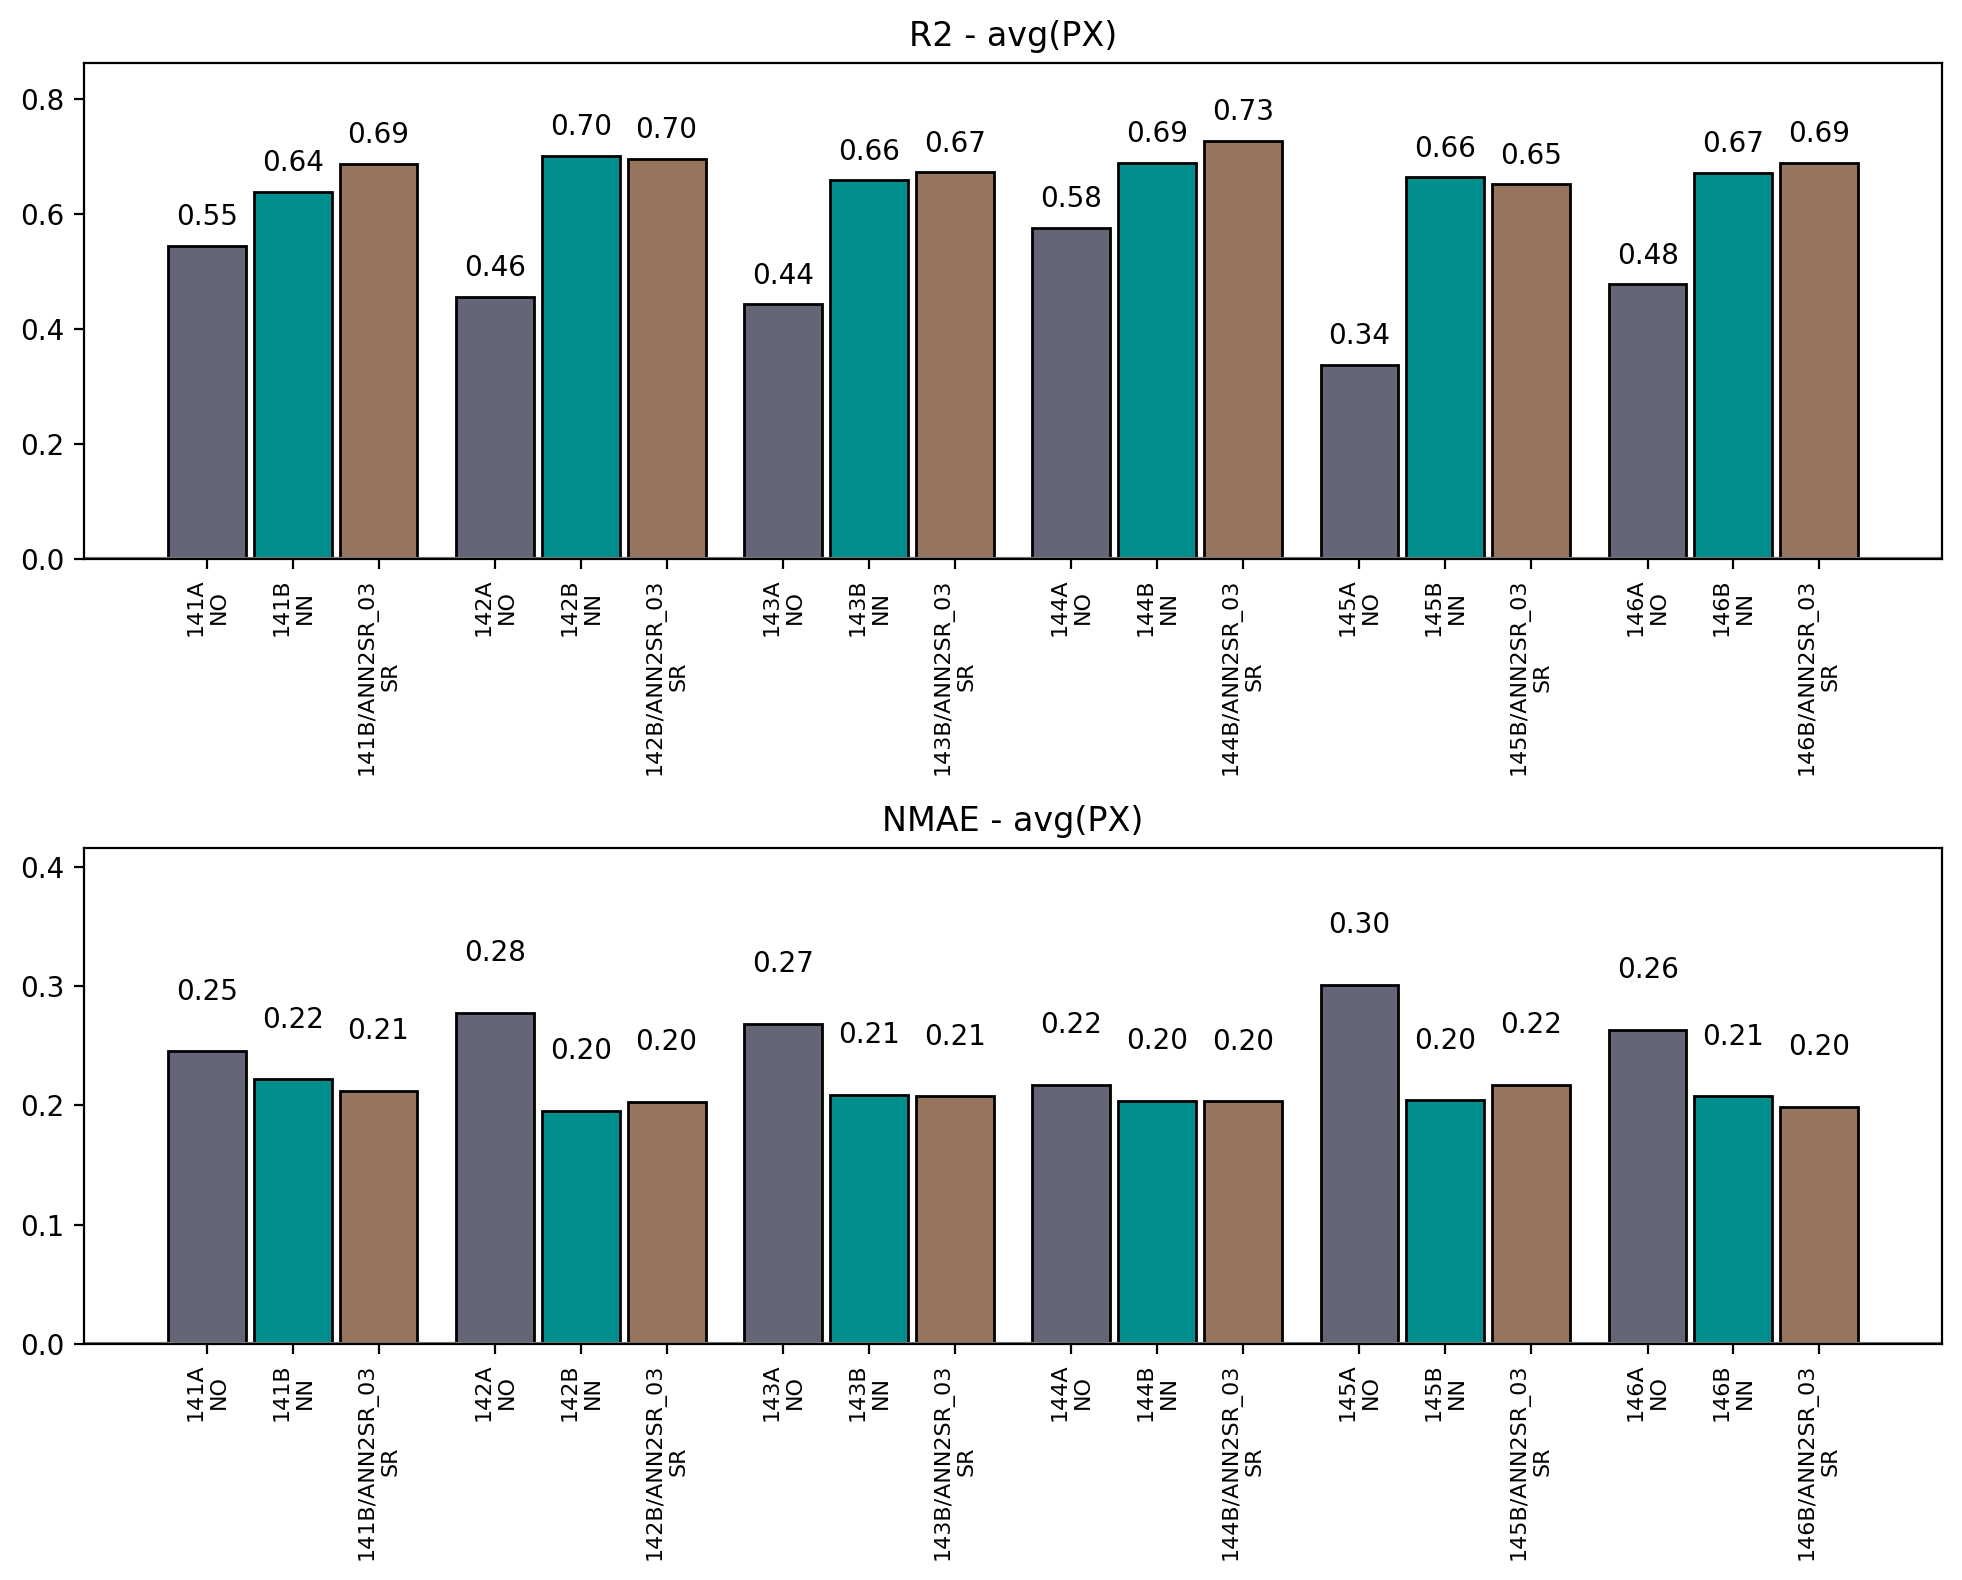

In [4]:
importlib.reload(AF)
METRIC_index = 1
suptitle = labels[METRIC_index]
AF.plot_compare_versions(versions, metrics, METRIC_values, 
                         METRIC_index=METRIC_index, 
                         suptitle=suptitle)

## Figure: R2 Comparison

Size: (1500, 900) New Size: (np.int64(46), np.int64(45), np.int64(1458), np.int64(855))
Already up to date.
On branch master
Your branch is ahead of 'origin/master' by 2 commits.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean


remote: Updating references: 100% (1/1)           
To https://git.overleaf.com/688f5daf4e30e6d98498e7b8
   d2b02da..92e89a9  master -> master


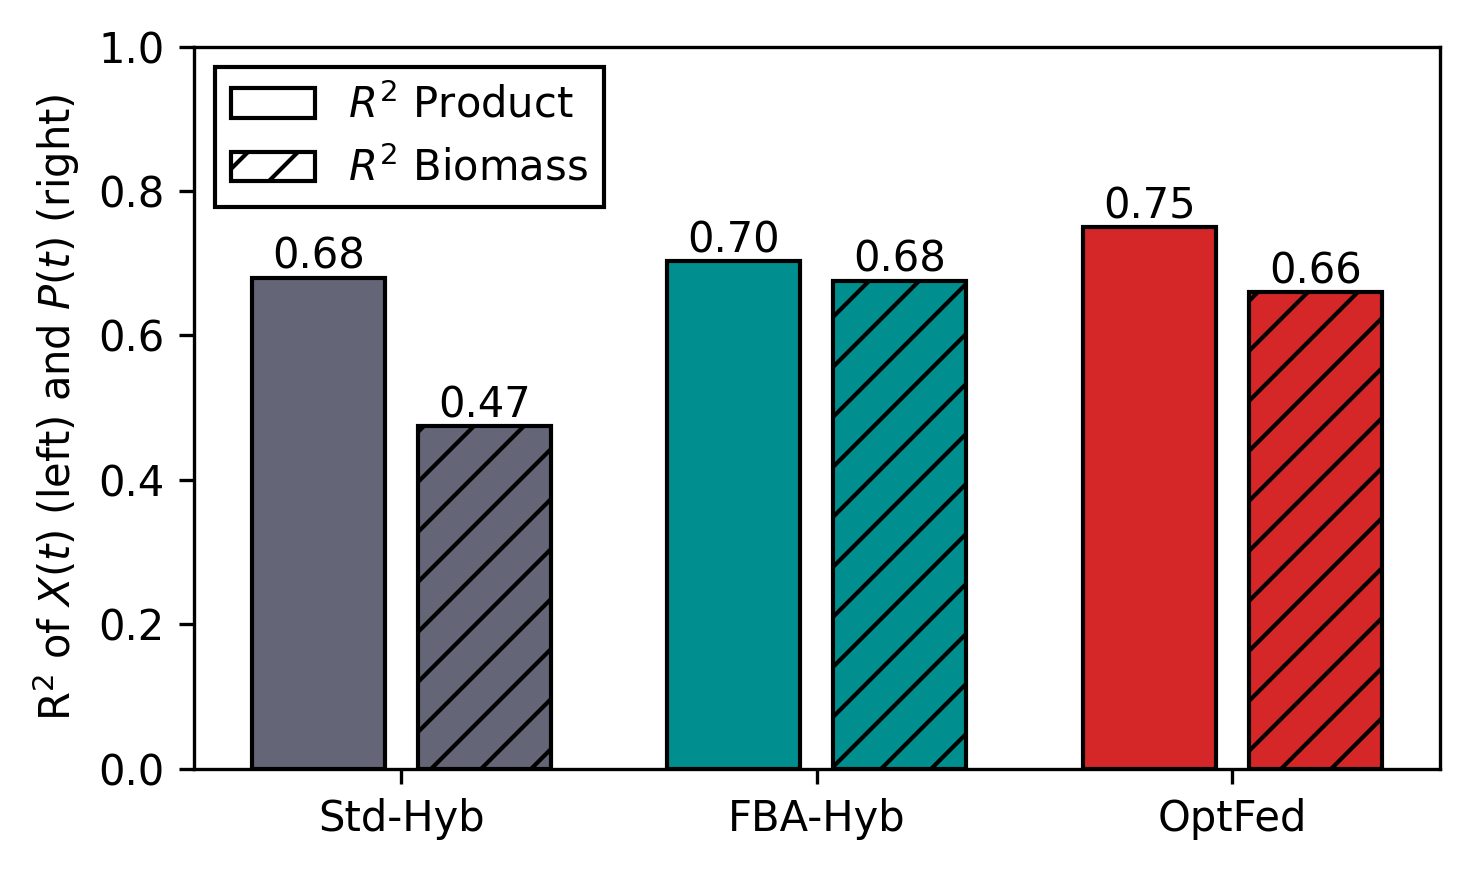

In [6]:
plt.figure(dpi=300,figsize=(5,3))

std_version = "MPM_144A"
fba_version = "MPM_144B"
metric_value_index = metrics.index("R2")

# optfed
lP = .75
lX = .66
l0 = 5
plt.bar( l0+0, lP,color="C3",edgecolor="k")
plt.bar( l0+1, lX,color="C3",edgecolor="k",hatch="//")
plt.text(l0+0, lP,f"{lP:.2f}",ha="center",va="bottom")
plt.text(l0+1, lX,f"{lX:.2f}",ha="center",va="bottom")

# Std-Hyb
lP = METRIC_values[0][std_version][3]
lX = METRIC_values[0][std_version][4]
l0 = 0
plt.bar( l0+0, lP,color=AF.get_color_from_fba_type("NO"),edgecolor="k")
plt.bar( l0+1, lX,color=AF.get_color_from_fba_type("NO"),edgecolor="k",hatch="//")
plt.text(l0+0, lP,f"{lP:.2f}",ha="center",va="bottom")
plt.text(l0+1, lX,f"{lX:.2f}",ha="center",va="bottom")

# FBA-Hyb + ANN2SR
lP = METRIC_values[0][fba_version][3]
lX = METRIC_values[0][fba_version][4]
l0 = 2.5
plt.bar( l0+0, lP,color=AF.get_color_from_fba_type("NN"),edgecolor="k")
plt.bar( l0+1, lX,color=AF.get_color_from_fba_type("NN"),edgecolor="k",hatch="//")
plt.text(l0+0, lP,f"{lP:.2f}",ha="center",va="bottom")
plt.text(l0+1, lX,f"{lX:.2f}",ha="center",va="bottom")

plt.bar(-10,.05,color="w",edgecolor="k",label="$R^2$ Product")
plt.bar(-10,.05,color="w",edgecolor="k",label="$R^2$ Biomass",hatch="//")
plt.legend(fancybox=False, edgecolor="k")

plt.ylim(0,1)
plt.xlim(-.75,6.75)
plt.xticks([.5,3,5.5],["Std-Hyb","FBA-Hyb","OptFed"])
plt.ylabel(f"R$^2$ of $X(t)$ (left) and $P(t)$ (right)")
plt.tight_layout()

# save_trim_push(git_path,"r2_comparison.png",dpi=300)
plt.show()

## Figure Manuscript Architecture Comparison

In [6]:
all_combis = np.array(
             [["MPM_141", "ann", "none"],
              ["MPM_142", "ann", "sigmoid"],
              ["MPM_143", "ann", "min"],
              ["MPM_144", "linear", "none"],
              ["MPM_145", "linear", "sigmoid"],
              ["MPM_146", "linear", "min"],])

def get_xticklab(version):
    # print(version[:7])
    i = np.where(all_combis[:,0] == version[:7])[0][0]

    return all_combis[i,1] + "\n" + all_combis[i,2]

def get_ylab(i):
    # metrics[i]
    if metrics[i] == "R2":
        str_1 = r"$R^2$"
    else:
        str_1 = metrics[i]
    if "avg" in suptitle:
        prefix = "mean"
        variables = suptitle.strip("avg()")
        var = ""
        for v in variables:
            var += f"${v}$ and "
        var = var.strip(" and ")
    else:
        prefix = ""
    return f"{prefix} {str_1} of {var}"

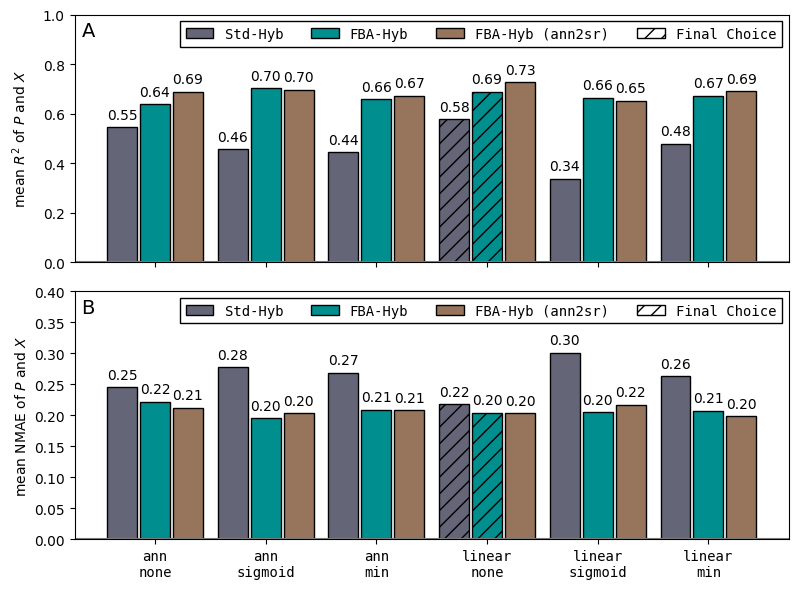

In [7]:
importlib.reload(AF)

fig = plt.figure(dpi=100,figsize=(8,6))
axes = []
for i in range(len(metrics)):
    axes.append(plt.subplot(len(metrics),1,i+1))

    axes[i].set_ylabel(get_ylab(i))

offset = 0
old_version = ""
locs = []
ymax = [1,.4]
laboff = [.05*m for m in ymax]
for i, version in enumerate(versions):
    if old_version != version.split("/")[0][-3:-1]:
        offset += .2
        old_version = version.split("/")[0][-3:-1]

    fba = AF.get_fba_type(version)
    c = AF.get_color_from_fba_type(fba)
    
    loc = i*.55+offset

    for j, metric in enumerate(metrics):
        value = METRIC_values[j][version][METRIC_index]
        text_value = np.max([value+laboff[j]])
        if i in [9,10]:
            hatch = "//"
        else:
            hatch = None
        axes[j].bar( loc,value,color=c,edgecolor="k",width=.5,hatch=hatch)
        axes[j].text(loc,text_value,f"{value:.2f}",va="center",ha="center")
    locs.append(loc)

# legend
for i, ax in enumerate(axes):
    ylim = ax.get_ylim()
    ax.set_ylim(0,ymax[i])
    ax.axhline(0,color="grey")
    ax.bar(5,-10,color=AF.get_color_from_fba_type("NO"),edgecolor="k",label="Std-Hyb")
    ax.bar(5,-10,color=AF.get_color_from_fba_type("NN"),edgecolor="k",label="FBA-Hyb")
    ax.bar(5,-10,color=AF.get_color_from_fba_type("SR"),edgecolor="k",label="FBA-Hyb (ann2sr)")
    ax.bar(5,-10,color="w",edgecolor="k",hatch="//",label="Final Choice")
    legend = ax.legend(ncols=4)
    for text in legend.get_texts():
        text.set_fontfamily('monospace')

# panel letters
import matplotlib.transforms as mtransforms
for name, ax in zip(['A','B','C','D','E','F'],axes):
    trans = mtransforms.ScaledTranslation(5/72, -5/72, fig.dpi_scale_trans)
    ax.text(0.0, 1.0, name, transform=ax.transAxes + trans,
    fontsize=14, verticalalignment='top', fontfamily='sans',
    bbox=dict(facecolor='none', edgecolor='none', pad=3.0))

axes[0].set_ylim(0,1)
axes[1].set_ylim(0,.4)
axes[0].set_xticks(np.array(locs)[1::3],["" for v in versions[::3]])
axes[1].set_xticks(np.array(locs)[1::3],[get_xticklab(v) for v in versions[::3]])
# Apply monospace font to the tick labels
for label in axes[1].get_xticklabels():
    label.set_fontfamily('monospace')
fig.align_ylabels()

plt.tight_layout()
# save_trim_push(git_path,"r2_architecture.png",dpi=300)
plt.show()

In [8]:
METRIC_index = 1

for metric_name_idx, metric in enumerate(metrics):
    tmp_metric_list_A = []
    tmp_metric_list_B = []
    for version in versions:
        if "SR" in version:
            pass
        elif "A" in version.split("/")[0]:
            tmp_metric_list_A.append(METRIC_values[metric_name_idx][version][METRIC_index])
        elif "B" in version.split("/")[0]:
            tmp_metric_list_B.append(METRIC_values[metric_name_idx][version][METRIC_index])
        else:
            raise ValueError("Version not recognized.")
    tmp_metric_list_A = np.array(tmp_metric_list_A)
    tmp_metric_list_B = np.array(tmp_metric_list_B)
    avg_A = np.mean(tmp_metric_list_A)
    avg_B = np.mean(tmp_metric_list_B)
    diff = avg_B - avg_A
    rel_diff = diff / np.abs(avg_A) * 100
    print(f"{metric:10} Avg A: {avg_A:.3f}, Avg B: {avg_B:.3f}, Rel Diff: {rel_diff:.2f}%")
    # break

R2         Avg A: 0.473, Avg B: 0.671, Rel Diff: 41.87%
NMAE       Avg A: 0.262, Avg B: 0.207, Rel Diff: -21.06%


In [9]:
METRIC_index = 1

for metric_name_idx, metric in enumerate(metrics):
    tmp_metric_list_A = []
    tmp_metric_list_B = []
    for version in versions:
        if len(version.split("/"))>1:
            tmp_metric_list_A.append(METRIC_values[metric_name_idx][version][METRIC_index])
        elif "B" in version.split("/")[0]:
            tmp_metric_list_B.append(METRIC_values[metric_name_idx][version][METRIC_index])
        else:
            pass
    tmp_metric_list_A = np.array(tmp_metric_list_A)
    tmp_metric_list_B = np.array(tmp_metric_list_B)
    avg_A = np.mean(tmp_metric_list_A)
    avg_B = np.mean(tmp_metric_list_B)
    diff = avg_B - avg_A
    rel_diff = diff / np.abs(avg_A) * 100
    print(f"{metric:10} Avg SR: {avg_A:.3f}, Avg B: {avg_B:.3f}, Rel Diff: {rel_diff:.3f}%")
    # break

R2         Avg SR: 0.688, Avg B: 0.671, Rel Diff: -2.434%
NMAE       Avg SR: 0.207, Avg B: 0.207, Rel Diff: -0.014%


# Generate Ensemble Model

In [11]:
# load the experimental dataframes and scalers from one model version (they are all the same)
#--- INPUTs
base_path = "/mnt/y/code/250513_metabolic_process_models/prol_model_scripts/"
model_path = f"{base_path}/MPM_141B.py"
set_number = 2

MM = UF.import_module_from_path(model_path)
cross_valid_sets = MM.HF.get_valid_sets()
scalers, ALL_kwargs = MM.get_model_config()
exp_dataframes = MM.get_exp_dfs()
aug_dataframes = MM.get_aug_dfs()

#-------------------- CONFIG --------------------#
fba_type          : SRfba
base_flux_type    : ann
LIM_handler_type  : none
modify_ann_inp    : none
extra_metabolites : False
#------------------------------------------------#


In [12]:
print("load DATA")
EXP_DATA_process_names = ['DoE1_R1', 'DoE1_R2', 'DoE1_R3', 'DoE1_R4', 
                        'DoE2_R1', 'DoE2_R2', 'DoE2_R3', 'DoE2_R4', 
                        'DoE3_R1', 'DoE3_R2', 'DoE3_R3', 'DoE3_R4']
EXP_DATA = DF.PRE_process_data(exp_dataframes,scalers,
                            EXP_DATA_process_names,
                            inverse=True,
                            yi_method="copy",
                            Ycols=["G","P","X","V_N"],
                            Ucols=["t","T","Cf_N","G_Cf"],
                            verbose=False)

load DATA


In [13]:
# this are the best performing model architectures for StdHyb and FBAHyb

versions = ['MPM_144A', 'MPM_144B']

ENS_models = {}
for version in versions: 
    print(version)
    if "MM" in vars():
        del MM

    # get model configs and scalers
    base_path = "/mnt/y/code/250513_metabolic_process_models/prol_model_scripts/"
    model_path = f"{base_path}/{version.split('/')[0]}.py"
    MM = UF.import_module_from_path(model_path)
    cross_valid_sets = MM.HF.get_valid_sets()
    scalers, ALL_kwargs = MM.get_model_config(verbose=False)

    models = []
    for set_index in range(len(cross_valid_sets)):
        ODE_kwargs, TRAIN_kwargs = ALL_kwargs
        ODE_kwargs["verbose"] = False
        model = MM.ODE(**ODE_kwargs)
        model = eqx.nn.inference_mode(model)

        if "ANN2SR" in version:
            model = HF.PYSR_model_loader(
                mpm_version = version.split("/")[0],
                pysr_version = version.split("/")[1],
                dataset_name = "optfed",
                base_model = model,
                set_name = f"set_{set_index+1}",
            )
        else:
            weights_path = model_path.replace("model_scripts","model_data").replace(".py",f"/set_{set_index+1}_last.eqx")
            model = eqx.tree_deserialise_leaves(weights_path, model)
            model = eqx.nn.inference_mode(model)
        models.append(model)
    # build an ensemble model from CV models
    ENS_model = MF.Ensemble(models)
    ENS_models[version] = ENS_model
    # break
print("DONE")

MPM_144A
MPM_144B
DONE


In [14]:
key = jax.random.PRNGKey(13)

print("ENSEMBLE MODELS METRICS")
metrics = ["R2","NMAE"]
for metric in metrics:
    print(f"--- {metric} ---")
    count = 0
    for version, SRfba_ENS in ENS_models.items():
        count += 1
        
        list_YY_true = []
        list_YY_pred = []
        # for i, data in enumerate(DATA):
        for i in range(EXP_DATA[0].shape[0]):
            data = [_[i:i+1] for _ in EXP_DATA]
            yy_true = data[0]
            YT, yy_pred = AF.parse_data_to_model(SRfba_ENS, data, key)
            # print(yy_pred.shape)
            # yy_pred = jnp.mean(yy_pred,axis=1)
            # print(yy_pred.shape)
            YY_true = SRfba_ENS.models[0].HYB.SCL_yy.unscale(yy_true)
            YY_pred = SRfba_ENS.models[0].HYB.SCL_yy.unscale(yy_pred[:,:,:SRfba_ENS.models[0].HYB.NR_state_variables])
            # AF.NEW_print_stats((YY_true, YY_pred), f"ensemble 121B set {i+1}", header=i==0,verbose=True,metric=metric)
            list_YY_true.append(YY_true)
            list_YY_pred.append(YY_pred)
            # break
        list_YY_true = jnp.concatenate(list_YY_true,axis=0)
        list_YY_pred = jnp.concatenate(list_YY_pred,axis=0)
        AF.NEW_print_stats((list_YY_true, list_YY_pred), 
                           f"ENS {version}", 
                           header=count==1,verbose=True,metric=metric)


ENSEMBLE MODELS METRICS
--- R2 ---
                          | avg(GPX) | avg(PX)  | G        | P        | X        | V        | P/X      | 
---------------------------------------------------------------------------------------------------------
             ENS MPM_144A |   0.8259 |   0.7645 |   0.9487 |   0.8076 |   0.7214 |   0.9985 |   0.6440 |  
             ENS MPM_144B |   0.8653 |   0.8205 |   0.9547 |   0.7968 |   0.8443 |   0.9985 |   0.6244 |  
--- NMAE ---
                          | avg(GPX) | avg(PX)  | G        | P        | X        | V        | P/X      | 
---------------------------------------------------------------------------------------------------------
             ENS MPM_144A |   0.1943 |   0.1685 |   0.2460 |   0.2360 |   0.1010 |   0.0095 |   0.2982 |  
             ENS MPM_144B |   0.1786 |   0.1549 |   0.2259 |   0.2435 |   0.0663 |   0.0089 |   0.3057 |  


## Figure: Mass Balance Viol

In [15]:
# --- 0. load FBA model to check for mass balance violations ---
FBAmodel = cobra.io.read_sbml_model("/mnt/y/code/250513_metabolic_process_models/prol_fba_data/250414_iEC1356_reduced.xml")

# --- 1. Define bounds from experimental data ---
off_df = exp_dataframes[0].loc[~exp_dataframes[0].process.str.contains("VAL")]
onl_df = exp_dataframes[1].loc[~exp_dataframes[1].process.str.contains("VAL")]
SCL_yy, SCL_uu = scalers

YY_cols = ["G", "P", "X", "V_N"]
UU_cols = ["t", "T", "Cf_N", "G_Cf"]

YY_min = jnp.array(off_df[YY_cols].min().values)
YY_max = jnp.array(off_df[YY_cols].max().values)

# Use numpy.isclose to stay in Pandas world
mask_t0 = np.isclose(off_df["t"].values, 0)
YI_min = jnp.array(off_df.loc[mask_t0, YY_cols].min().values)
YI_max = jnp.array(off_df.loc[mask_t0, YY_cols].max().values)

UU_min = jnp.array(onl_df[UU_cols].min().values)
UU_max = jnp.array(onl_df[UU_cols].max().values)

print("Bounds:")
for name, lo, hi in zip(YY_cols, YY_min, YY_max):
    print(f"YY {name:<5}: {lo:.3g} - {hi:.3g}")
for name, lo, hi in zip(UU_cols, UU_min, UU_max):
    print(f"UU {name:<5}: {lo:.3g} - {hi:.3g}")

# --- 2. Latin Hypercube Sampling (JAX implementation) ---
def lhs_jax(key, n_samples, n_dim):
    """Latin Hypercube Sampling implemented with JAX."""
    key, subkey1, subkey2 = jax.random.split(key, 3)
    u = jax.random.uniform(subkey1, shape=(n_samples, n_dim))
    # stratify and permute each dimension independently
    a = (jnp.arange(n_samples)[:, None] + u) / n_samples
    perm_keys = jax.random.split(subkey2, n_dim)
    perm = jnp.stack([jax.random.permutation(k, a[:, i]) for i, k in enumerate(perm_keys)], axis=1)
    return perm, key

# --- 3. Generate samples for each input group ---
n_samples = 1000  # adjust for resolution
key = jax.random.PRNGKey(0)

yy_unit, key = lhs_jax(key, n_samples, len(YY_min))
yi_unit, key = lhs_jax(key, n_samples, len(YI_min))
uu_unit, key = lhs_jax(key, n_samples, len(UU_min))

yy_samples = YY_min + yy_unit * (YY_max - YY_min)
yi_samples = YI_min + yi_unit * (YI_max - YI_min)
uu_samples = UU_min + uu_unit * (UU_max - UU_min)

# --- 4. Scale inputs for model ---
yy_inputs = jnp.stack([SCL_yy.scale(v) for v in yy_samples])
yi_inputs = jnp.stack([SCL_yy.scale(v) for v in yi_samples])
uu_inputs = jnp.stack([SCL_uu.scale(v) for v in uu_samples])

print("\nLHS Sampling complete:")
print("yy_inputs:", yy_inputs.shape)
print("yi_inputs:", yi_inputs.shape)
print("uu_inputs:", uu_inputs.shape)

# --- Compute unscaled min/max for comparison ---
yy_unscaled = jnp.array([SCL_yy.unscale(v) for v in yy_inputs])
yi_unscaled = jnp.array([SCL_yy.unscale(v) for v in yi_inputs])
uu_unscaled = jnp.array([SCL_uu.unscale(v) for v in uu_inputs])

yy_min_samp = yy_unscaled.min(axis=0)
yy_max_samp = yy_unscaled.max(axis=0)

yi_min_samp = yi_unscaled.min(axis=0)
yi_max_samp = yi_unscaled.max(axis=0)

uu_min_samp = uu_unscaled.min(axis=0)
uu_max_samp = uu_unscaled.max(axis=0)

print("\nSampled ranges (after LHS sampling):")
for name, lo, hi in zip(YY_cols, yy_min_samp, yy_max_samp):
    print(f"YY {name:<5}: {float(lo):.3g} - {float(hi):.3g}")
for name, lo, hi in zip(YY_cols, yi_min_samp, yi_max_samp):
    print(f"YI {name:<5}: {float(lo):.3g} - {float(hi):.3g}")
for name, lo, hi in zip(UU_cols, uu_min_samp, uu_max_samp):
    print(f"UU {name:<5}: {float(lo):.3g} - {float(hi):.3g}")

Bounds:
YY G    : 0 - 141
YY P    : 0 - 9.87
YY X    : 21.2 - 70.2
YY V_N  : 0.889 - 4.04
UU t    : 0 - 12.3
UU T    : 298 - 317
UU Cf_N : 0.00117 - 0.629
UU G_Cf : 360 - 370

LHS Sampling complete:
yy_inputs: (1000, 4)
yi_inputs: (1000, 4)
uu_inputs: (1000, 4)

Sampled ranges (after LHS sampling):
YY G    : 0.00103 - 141
YY P    : 0.000206 - 9.86
YY X    : 21.2 - 70.1
YY V_N  : 0.89 - 4.04
YI G    : 5.23e-05 - 0.501
YI P    : 0 - 0
YI X    : 21.2 - 45.1
YI V_N  : 0.889 - 1.33
UU t    : 0.00101 - 12.3
UU T    : 298 - 317
UU Cf_N : 0.00176 - 0.629
UU G_Cf : 360 - 370


In [16]:
def get_inter_from_ENS(model,yy,yi,uu,key):
    """
    This just takes an Ensemble model and inputs, converts the control inputs in spline outputs and gets the intermediates
    """


    # u is parsed to the model as backward hermite coefficients of a spline
    uu = uu.reshape(1,-1)  # shape (1, 4)
    uu_tiled = jnp.tile(uu, (1,50, 1))   # shape (50, 4)
    UT = jnp.linspace(0,13).reshape(1,-1,1)
    uc = DF.PRE_calculate_control_spline(uu = uu_tiled,
                                            UT = UT,
                                            verbose=False)
    control = dfx.CubicInterpolation(UT[0,:,0], uc[0,:])
    inter = model.get_intermediates(6,yy,(control,key,yi))
    return inter

# Get the intermediate values of the ODEs for all ensemble models and all input combinations

ENS_intermediates = {}
for version, ens in ENS_models.items():
    print(version)
    inter = jax.vmap(get_inter_from_ENS, in_axes=(None,0,0,0,None))(ens,yy_inputs,yi_inputs,uu_inputs,key)
    # print_dict_array_shapes(inter)
    def arr_get_V_rel(V_out):
        def get_V_rel(V_out):
            return jnp.take(V_out,ens.models[0].HYB.IDX_q_rel)
        return jax.vmap(get_V_rel)(V_out)
    inter["V_rel"] = jax.vmap(arr_get_V_rel)(inter["V_out"])
    ENS_intermediates[version] = inter
    # break   
print("done")

MPM_144A
MPM_144B
done


In [17]:
# Do a real FBA and check if the solution would be feasible.

fba_analysis = {}
for version, inter in ENS_intermediates.items():
    print(version)
    inter = ENS_intermediates[version]

    # V_rel_avg = inter["V_rel"][:,1,:] 
    V_rel_avg = jnp.mean(inter["V_rel"],axis=1)

    constr_violations = []
    magnitudes = []
    for TMP_V_rel in V_rel_avg:
        with FBAmodel as TMP:
            TMP.reactions.protein_synthesis.lower_bound
            TMP.reactions.protein_synthesis.bounds = TMP_V_rel[1],TMP_V_rel[1]
            TMP.reactions.BIOMASS_Ec_iJO1366_core_53p95M.bounds = TMP_V_rel[2],TMP_V_rel[2]
            TMP.reactions.ATPM.bounds = 0, 1000
            TMP.reactions.EX_glyc_e_i.bounds = 0, 1000
            TMP.objective = "EX_glyc_e_i"
            TMP.objective_direction = "min"
            solution = TMP.optimize()
        constr_viol = solution["EX_glyc_e_i"] > TMP_V_rel[0]
        magnitude = (solution["EX_glyc_e_i"] / TMP_V_rel[0] - 1) * 100 if constr_viol else 0
        # print(constr_viol, magnitude)
        constr_violations.append(constr_viol)
        magnitudes.append(magnitude)
        # break

    constr_violations = jnp.array(constr_violations)
    magnitudes = jnp.array(magnitudes)
    fba_analysis[version] = {"constr_violations":constr_violations,
                                "magnitudes":magnitudes,
                             }
print("done")

MPM_144A
MPM_144B
done


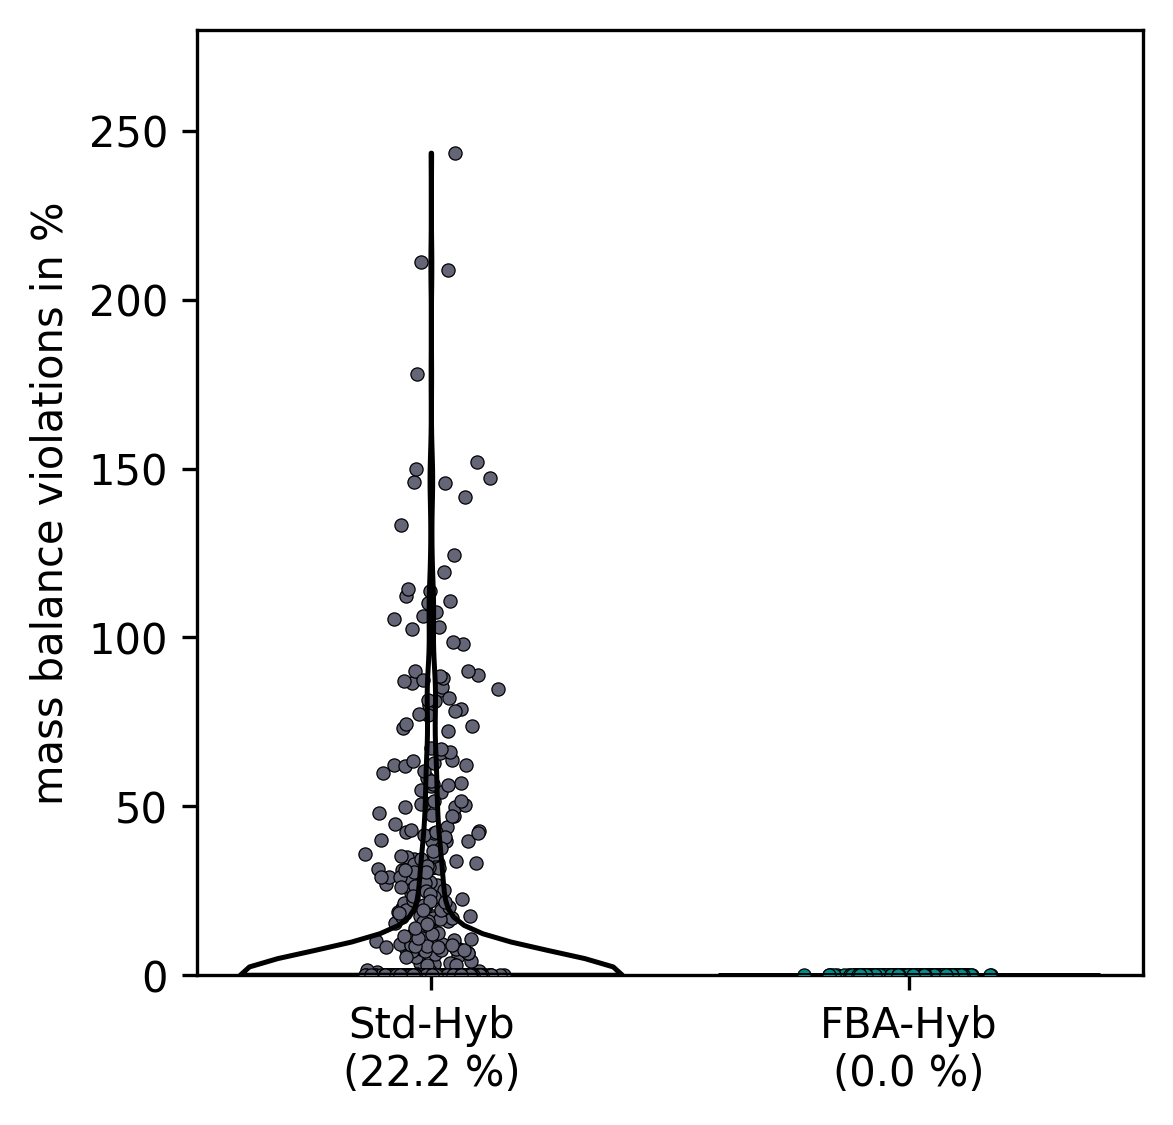

In [18]:
importlib.reload(AF)

plt.figure(dpi=300, figsize=(4, 4))
plt.subplot(111, box_aspect=1)

models = [
    ("MPM_144A", "Std-Hyb"),
    ("MPM_144B", "FBA-Hyb"),
]
labels = []
for pos, (model_name, label) in enumerate(models, start=1):
    color = AF.get_color_from_fba_type(AF.get_fba_type(version=model_name))
    vals = fba_analysis[model_name]["magnitudes"]
    cv = fba_analysis[model_name]["constr_violations"]
    cv_percent = jnp.sum(cv) / cv.shape[0] * 100

    # violin with only outlines (no fill)
    v = plt.violinplot(
        vals,
        positions=[pos],
        widths=0.8,
        showextrema=False,
    )
    for b in v["bodies"]:
        b.set_facecolor("none")       # no fill
        b.set_edgecolor("black")      # black outline
        b.set_linewidth(1.2)
        b.set_alpha(1.0)
        b.set_zorder(10)

    # scatter overlay
    plt.scatter(
        np.ones_like(vals) * pos + np.random.normal(0, 0.05, vals.shape),
        vals,
        edgecolor="k",
        facecolor=color,
        s=10,
        alpha=1,
        zorder=5,
        linewidths=0.3
    )

    # text label (violation %)
    # plt.text(
    #     pos,
    #     float(max(vals)) + 10,
    #     f"{cv_percent:.1f} %",
    #     ha="center",
    #     va="center",
    #     fontsize=8,
    # )
    labels.append(f"{label}\n({cv_percent:.1f} %)")

# final styling
plt.xticks(range(1, len(models) + 1), labels)#, fontfamily="monospace")
plt.ylim(0, 280)
plt.ylabel("mass balance violations in %")
plt.tight_layout()

#### save_trim_push(git_path,"mass_balance_violations.png",dpi=300)
plt.show()


In [24]:
vals = fba_analysis["MPM_144A"]["magnitudes"]
print(np.mean(vals))
vals = fba_analysis["MPM_144B"]["magnitudes"]
print(np.mean(vals))

9.953588
0.0


## Figure: n(t) and q(t)

In [25]:
importlib.reload(AF)
model = ENS_models["MPM_144B"]

process_idx = 3
key = jax.random.PRNGKey(0)
TRUE = AF.NEW_get_predictions(model, [_[process_idx:process_idx+1] for _ in EXP_DATA], key, mode="true")
PRED = AF.NEW_get_predictions(model, [_[process_idx:process_idx+1] for _ in EXP_DATA], key, mode="pred")
SMTH = AF.NEW_get_predictions(model, [_[process_idx:process_idx+1] for _ in EXP_DATA], key, mode="smth")
print("TRUE", TRUE["y"].shape, TRUE["t"].shape, TRUE["u"].shape, TRUE["V_out"].shape)
print("PRED", PRED["y"].shape, PRED["t"].shape, PRED["u"].shape, PRED["V_out"].shape)
print("SMTH", SMTH["y"].shape, SMTH["t"].shape, SMTH["u"].shape, SMTH["V_out"].shape)

(7,) (7, 4)
(7,) (7, 4)
(1000,) (1000, 4)
TRUE (1, 7, 4) (1, 7) (1, 7, 4) (1, 7, 8)
PRED (1, 7, 4) (1, 7) (1, 7, 4) (1, 7, 8)
SMTH (1, 1000, 4) (1, 1000) (1, 1000, 4) (1, 1000, 8)


In [26]:
def normizer(a):
        a = jnp.abs(a)
        s = jnp.sum(a)+1e-8
        return a/s

def multiply_by_qGqI(a):
      s = jnp.array([17.331666759259424,698.3381234567888,0.07407407407407551])
      return a * s

SCL_n = DF.SCL_init_from_fba(["nr_X","nr_P","nr_M"],"mean")
FBA_inp = SMTH["FBA_inp"] # qG, nX, nP, nM

# these are scaled values are already averaged
n = FBA_inp[0,:,1:4]
# first we want them to add up to 1
n = jax.vmap(normizer)(n)
# then unscale
n = SCL_n.unscale(n)
# then multiply by the qG/qI ratios to get qG-equivalents
n = jax.vmap(multiply_by_qGqI)(n)
n = jax.vmap(normizer)(n)
print(FBA_inp.shape)
# print(FBA_inp_avg.shape)    
print(n.shape)

qG = SMTH["V_out"][0,:,0]
q = jax.vmap(multiply_by_qGqI)(jnp.take(SMTH["V_out"][0,:,:],jnp.array([2,1,3]),axis=1))

(1, 1000, 4)
(1000, 3)


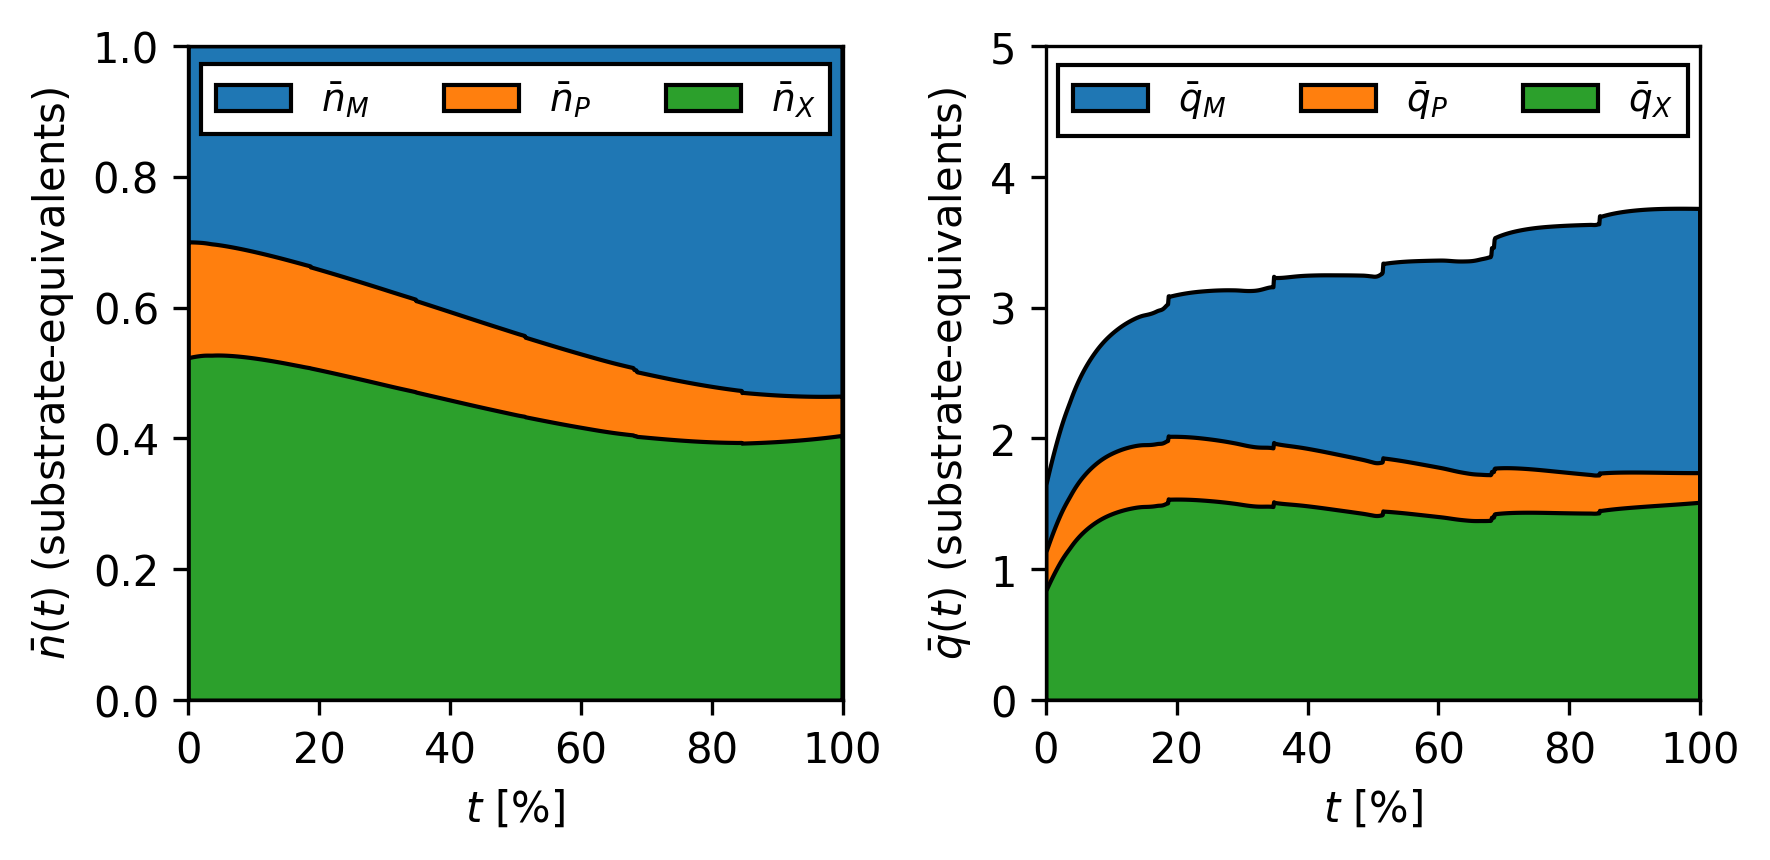

In [27]:
plt.figure(dpi=300, figsize=(6, 4))
tt = jnp.arange(1000) #SMTH["t"] <- this would be the abs time

ax1 = plt.subplot(121, box_aspect=1)

plt.fill_between(tt,n[:,2]+n[:,0]+n[:,1],label=r"$\bar{n}_M$",edgecolor="k")
plt.fill_between(tt,n[:,1]+n[:,0],label=r"$\bar{n}_P$",edgecolor="k")
plt.fill_between(tt,n[:,0],label=r"$\bar{n}_X$",edgecolor="k")

plt.ylim(0,1)
plt.ylabel(r"$\bar{n}(t)$ (substrate-equivalents)")
plt.legend(fancybox=False,framealpha=1,edgecolor="k",loc="upper center",ncol=3,fontsize=9)

ax2 = plt.subplot(122, box_aspect=1)
# plt.plot(qG,label="qG")
# plt.plot(q[:,0],label="X")
# plt.plot(q[:,1],label="P")
# plt.plot(q[:,2],label="M")
plt.fill_between(tt,q[:,2]+q[:,0]+q[:,1],label=r"$\bar{q}_M$",edgecolor="k")
plt.fill_between(tt,q[:,1]+q[:,0],label=r"$\bar{q}_P$",edgecolor="k")
plt.fill_between(tt,q[:,0],label=r"$\bar{q}_X$",edgecolor="k")
# plt.plot(jnp.sum(q,axis=1),ls="--",label="q_total") # sanity check. works
plt.ylabel(r"$\bar{q}(t)$ (substrate-equivalents)")
plt.ylim(0,5)

for ax in [ax1,ax2]:

    ax.set_xlim(0,1000)
    ax.set_xlabel(r"$t$ [%]")
    ax.set_xticks([i for i in ax.get_xticks()])
    ax.set_xticklabels([f"{i/10:.0f}" for i in ax.get_xticks()])
plt.legend(fancybox=False,framealpha=1,edgecolor="k",loc="upper center",ncol=3,fontsize=9)
plt.tight_layout()
#### save_trim_push(git_path,"n_and_q.png",dpi=300)
plt.show()

In [40]:
print("nP over time")
i = 1
n[:,i].shape
print(n[0,i],n[-1,i])
print((1-n[-1,i]/n[0,i])*100,"% decrease")

print("nM over time")
i = 2
n[:,i].shape
print(n[0,i],n[-1,i])
print((1-n[-1,i]/n[0,i])*100,"% decrease")

print("nX over time")
i = 0
n[:,i].shape
print(n[0,i],n[-1,i])
print((1-n[-1,i]/n[0,i])*100,"% decrease")

nP over time
0.17699055 0.06015229
66.01384 % decrease
nM over time
0.29968396 0.53528786
-78.617455 % decrease
nX over time
0.5233255 0.40455982
22.69442 % decrease


## Figure: Combined: Mass Balance Viol & n and q over time

Size: (3000, 1200) New Size: (np.int64(44), np.int64(206), np.int64(2952), np.int64(1088))


From https://git.overleaf.com/688f5daf4e30e6d98498e7b8
   79da1ab..3400e09  master     -> origin/master


Updating 79da1ab..3400e09
Fast-forward
 figures/n_and_q.png                      | Bin 95353 -> 0 bytes
 figures/training_flowsheet_latex_v01.pdf | Bin 101090 -> 0 bytes
 figures/u_to_n.png                       | Bin 220306 -> 0 bytes
 3 files changed, 0 insertions(+), 0 deletions(-)
 delete mode 100644 figures/n_and_q.png
 delete mode 100644 figures/training_flowsheet_latex_v01.pdf
 delete mode 100644 figures/u_to_n.png
[master ba4a1af] comb_mbv_nq.png
 1 file changed, 0 insertions(+), 0 deletions(-)


remote: Updating references: 100% (1/1)           
To https://git.overleaf.com/688f5daf4e30e6d98498e7b8
   3400e09..ba4a1af  master -> master


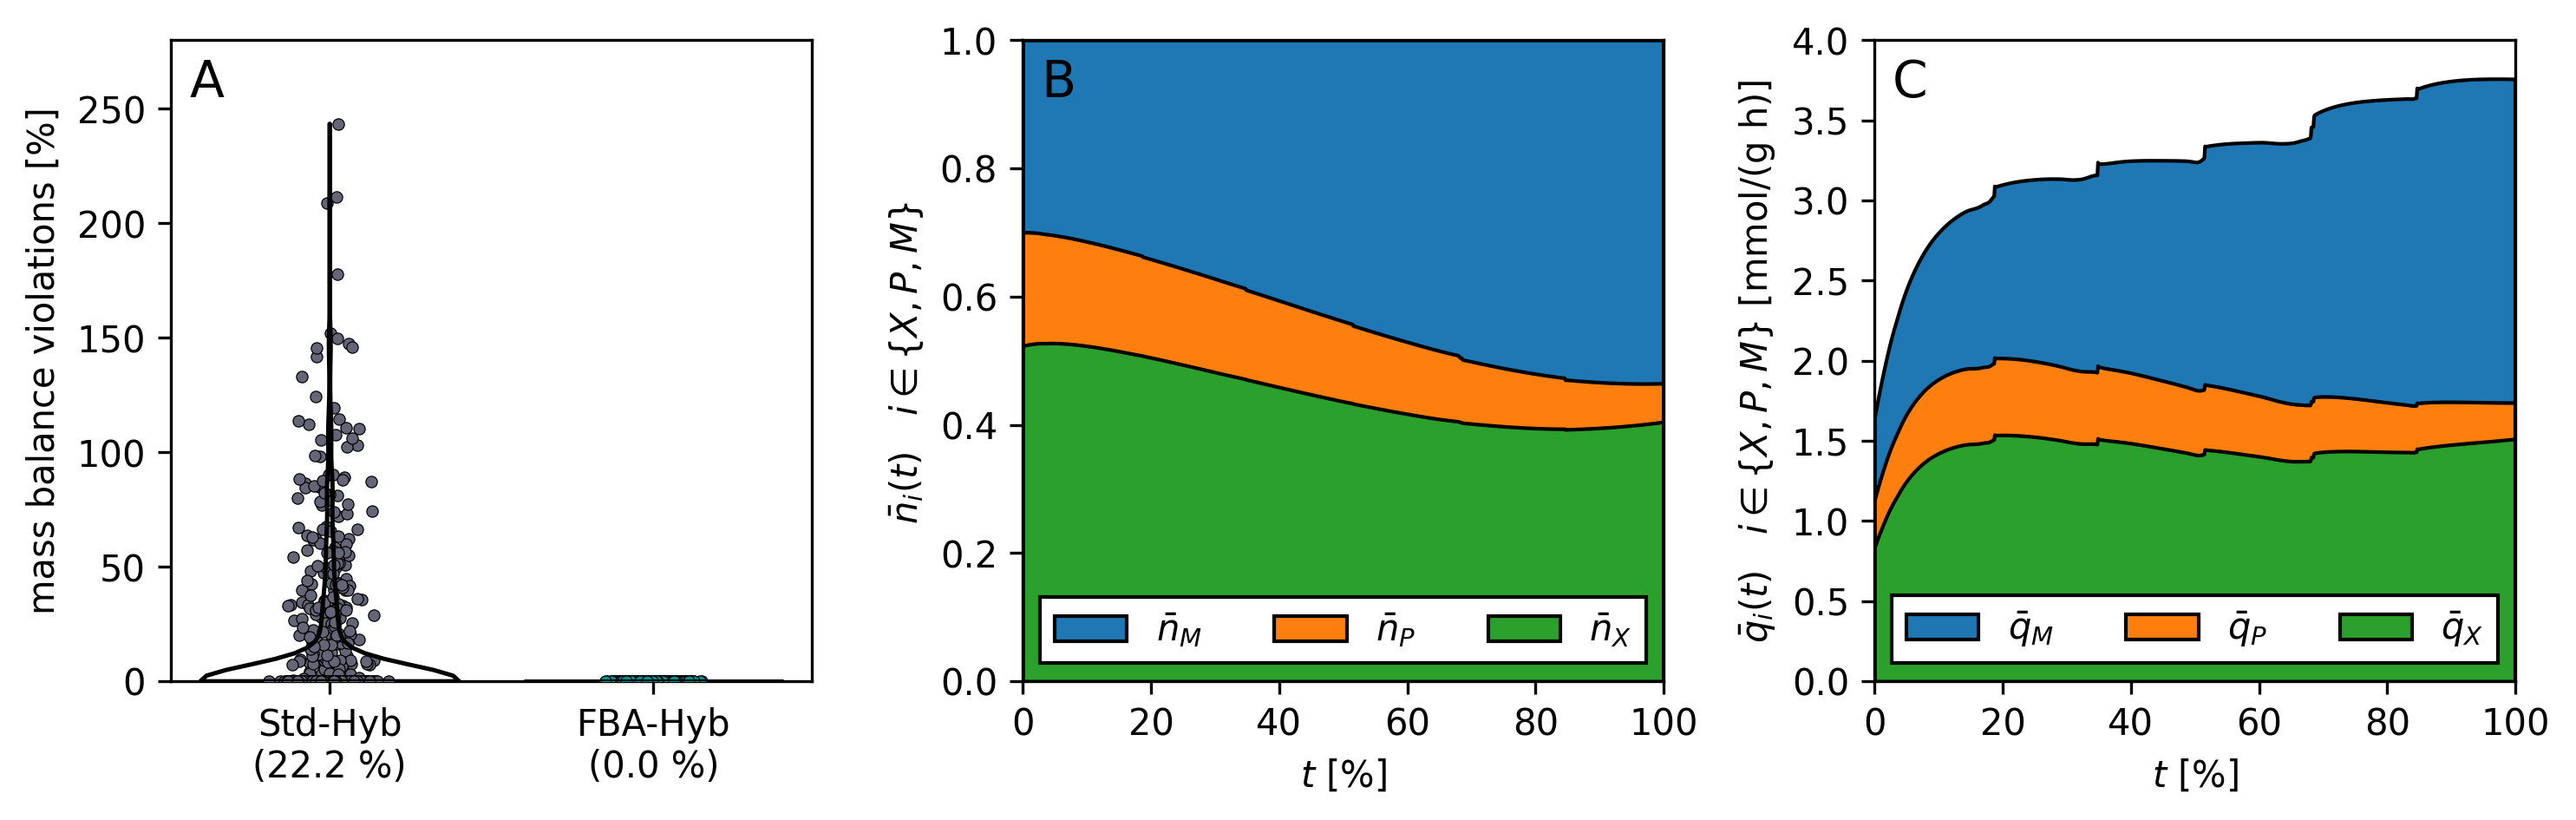

In [28]:
importlib.reload(AF)

fig = plt.figure(dpi=300, figsize=(10, 4))
ax0 = plt.subplot(131, box_aspect=1)

models = [
    ("MPM_144A", "Std-Hyb"),
    ("MPM_144B", "FBA-Hyb"),
]
labels = []
for pos, (model_name, label) in enumerate(models, start=1):
    color = AF.get_color_from_fba_type(AF.get_fba_type(version=model_name))
    vals = fba_analysis[model_name]["magnitudes"]
    cv = fba_analysis[model_name]["constr_violations"]
    cv_percent = jnp.sum(cv) / cv.shape[0] * 100

    # violin with only outlines (no fill)
    v = plt.violinplot(
        vals,
        positions=[pos],
        widths=0.8,
        showextrema=False,
    )
    for b in v["bodies"]:
        b.set_facecolor("none")       # no fill
        b.set_edgecolor("black")      # black outline
        b.set_linewidth(1.2)
        b.set_alpha(1.0)
        b.set_zorder(10)

    # scatter overlay
    plt.scatter(
        np.ones_like(vals) * pos + np.random.normal(0, 0.05, vals.shape),
        vals,
        edgecolor="k",
        facecolor=color,
        s=10,
        alpha=1,
        zorder=5,
        linewidths=0.3
    )
    labels.append(f"{label}\n({cv_percent:.1f} %)")

# final styling
plt.xticks(range(1, len(models) + 1), labels)#, fontfamily="monospace")
plt.ylim(0, 280)
plt.ylabel("mass balance violations [%]")
plt.tight_layout()

tt = jnp.arange(1000) #SMTH["t"] <- this would be the abs time

ax1 = plt.subplot(132, box_aspect=1)

plt.fill_between(tt,n[:,2]+n[:,0]+n[:,1],label=r"$\bar{n}_M$",edgecolor="k")
plt.fill_between(tt,n[:,1]+n[:,0],label=r"$\bar{n}_P$",edgecolor="k")
plt.fill_between(tt,n[:,0],label=r"$\bar{n}_X$",edgecolor="k")

plt.ylim(0,1)
# plt.ylabel(r"$\bar{n}_i(t) = n_iY_{i/G}^{-1} \quad i \in \{X, P, M\}$ ")
plt.ylabel(r"$\bar{n}_i(t) \quad i \in \{X, P, M\}$ ")
plt.legend(fancybox=False,framealpha=1,edgecolor="k",loc="lower center",ncol=3,fontsize=10)

ax2 = plt.subplot(133, box_aspect=1)
plt.fill_between(tt,q[:,2]+q[:,0]+q[:,1],label=r"$\bar{q}_M$",edgecolor="k")
plt.fill_between(tt,q[:,1]+q[:,0],label=r"$\bar{q}_P$",edgecolor="k")
plt.fill_between(tt,q[:,0],label=r"$\bar{q}_X$",edgecolor="k")
# plt.ylabel(r"$\bar{q}_i(t) = q_iY_{i/G}^{-1} \quad i \in \{X, P, M\}$ [mmol/(g h)]")
plt.ylabel(r"$\bar{q}_i(t) \quad i \in \{X, P, M\}$ [mmol/(g h)]")
plt.ylim(0,4)

for ax in [ax1,ax2]:

    ax.set_xlim(0,1000)
    ax.set_xlabel(r"$t$ [%]")
    ax.set_xticks([i for i in ax.get_xticks()])
    ax.set_xticklabels([f"{i/10:.0f}" for i in ax.get_xticks()])
plt.legend(fancybox=False,framealpha=1,edgecolor="k",loc="lower center",ncol=3,fontsize=10)

import matplotlib.transforms as mtransforms
for name, ax in zip(['A','B','C','D','E','F'],[ax0,ax1,ax2]):
    trans = mtransforms.ScaledTranslation(5/72, -5/72, fig.dpi_scale_trans)
    ax.text(0.0, 1.0, name, transform=ax.transAxes + trans,
    fontsize=14, verticalalignment='top', fontfamily='sans',
    bbox=dict(facecolor='none', edgecolor='none', pad=3.0))


plt.tight_layout()

save_trim_push(git_path,"comb_mbv_nq.png",dpi=300)
plt.show()


## Figure: q(t) for Std-Hyb

In [29]:
importlib.reload(AF)
model = ENS_models["MPM_144A"]

process_idx = 3
key = jax.random.PRNGKey(0)
TRUE = AF.NEW_get_predictions(model, [_[process_idx:process_idx+1] for _ in EXP_DATA], key, mode="true")
PRED = AF.NEW_get_predictions(model, [_[process_idx:process_idx+1] for _ in EXP_DATA], key, mode="pred")
SMTH = AF.NEW_get_predictions(model, [_[process_idx:process_idx+1] for _ in EXP_DATA], key, mode="smth")
print("TRUE", TRUE["y"].shape, TRUE["t"].shape, TRUE["u"].shape, TRUE["V_out"].shape)
print("PRED", PRED["y"].shape, PRED["t"].shape, PRED["u"].shape, PRED["V_out"].shape)
print("SMTH", SMTH["y"].shape, SMTH["t"].shape, SMTH["u"].shape, SMTH["V_out"].shape)

(7,) (7, 4)
(7,) (7, 4)
(1000,) (1000, 4)
TRUE (1, 7, 4) (1, 7) (1, 7, 4) (1, 7, 3)
PRED (1, 7, 4) (1, 7) (1, 7, 4) (1, 7, 3)
SMTH (1, 1000, 4) (1, 1000) (1, 1000, 4) (1, 1000, 3)


In [30]:
def normizer(a):
        a = jnp.abs(a)
        s = jnp.sum(a)+1e-8
        return a/s

def multiply_by_qGqI(a):
      s = jnp.array([17.331666759259424,698.3381234567888])
      return a * s

qG = SMTH["V_out"][0,:,0]
q = jax.vmap(multiply_by_qGqI)(jnp.take(SMTH["V_out"][0,:,:],jnp.array([2,1]),axis=1))

Size: (1800, 1200) New Size: (np.int64(260), np.int64(45), np.int64(1419), np.int64(1152))
Already up to date.
[master 5cc42cf] stdhyb_n_and_q.png
 1 file changed, 0 insertions(+), 0 deletions(-)


remote: Updating references: 100% (1/1)           
To https://git.overleaf.com/688f5daf4e30e6d98498e7b8
   ba4a1af..5cc42cf  master -> master


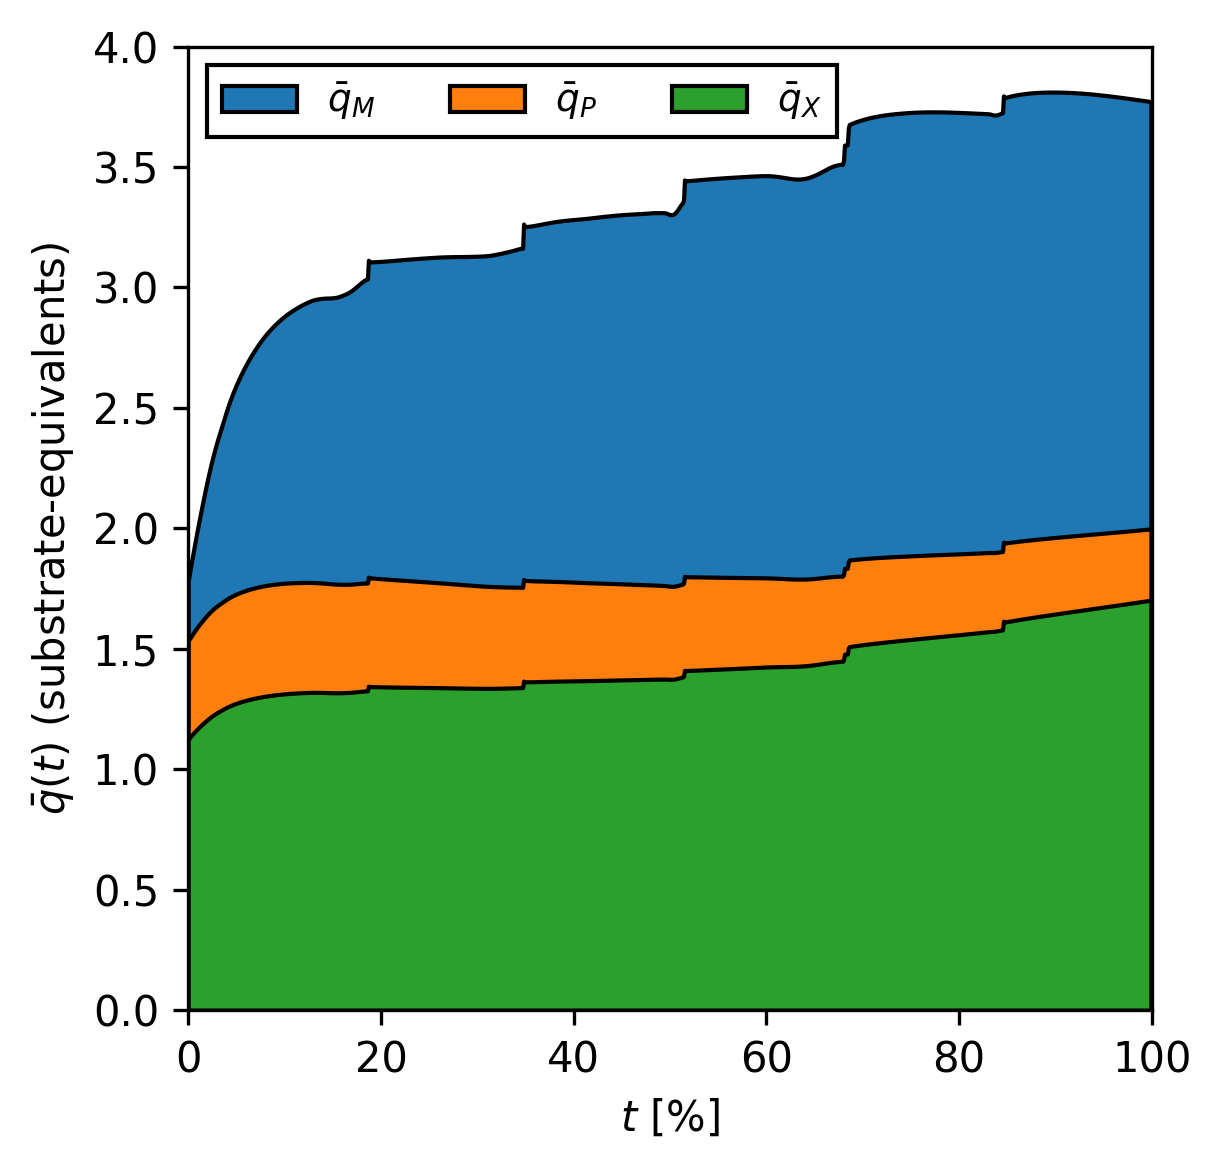

In [31]:
plt.figure(dpi=300, figsize=(6, 4))
tt = jnp.arange(1000) #SMTH["t"] <- this would be the abs time

ax2 = plt.subplot(111, box_aspect=1)
plt.fill_between(tt,qG,label=r"$\bar{q}_M$",edgecolor="k")
plt.fill_between(tt,q[:,1]+q[:,0],label=r"$\bar{q}_P$",edgecolor="k")
plt.fill_between(tt,q[:,0],label=r"$\bar{q}_X$",edgecolor="k")
plt.ylabel(r"$\bar{q}(t)$ (substrate-equivalents)")
plt.ylim(0,4)

for ax in [ax2]:
    ax.set_xlim(0,1000)
    ax.set_xlabel(r"$t$ [%]")
    ax.set_xticks([i for i in ax.get_xticks()])
    ax.set_xticklabels([f"{i/10:.0f}" for i in ax.get_xticks()])
plt.legend(fancybox=False,framealpha=1,edgecolor="k",loc="upper left",ncol=3,fontsize=9)
plt.tight_layout()
# save_trim_push(git_path,"stdhyb_n_and_q.png",dpi=300)
plt.show()